## Naive Bayes Notebook

This notebook builds and evaluates a Naive Bayes classifier for the Adult Income dataset, where the goal is to predict whether a person earns more than $50K. It walks through data preprocessing, train/test splitting, text-style feature extraction with `CountVectorizer`, model training with Bernoulli Naive Bayes, and standard evaluation metrics. It also compares preprocessing choices for continuous variables, visualizes performance trends and confusion-matrix results, and highlights the most class-indicative terms using log-likelihood ratios.

In [15]:
# Centralized imports used across the entire notebook.
import importlib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import adult_preprocessing
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB

from bokeh.io import output_notebook

output_notebook()

Loading BokehJS ...

## Data Preprocessing

### Feature Naming

When converting structured data to text, we prepend each column name to its values (e.g., `gender_Male`, `occupation_Technician`). This preserves feature identity in the vectorized representation, allowing the model to distinguish which feature contributed each token. Without this, different features with overlapping values could become ambiguous.

### Data Binning

Naive Bayes works best with features that have sufficient statistical support. Raw continuous values (e.g., `age_RAW_37`, `age_RAW_38`) create sparse tokens that compete for limited vocabulary space. Binning groups nearby values into categories (e.g., `age_BIN_35_44`), giving each feature more representation and helping the model learn more stable patterns.

In [16]:
# Load and configure the Adult dataset preprocessor module.
importlib.reload(adult_preprocessing)
AdultIncomePreprocessor = adult_preprocessing.AdultIncomePreprocessor
AdultPreprocessConfig = adult_preprocessing.AdultPreprocessConfig

# Choose preprocessing mode and instantiate the preprocessor.
config = AdultPreprocessConfig(
    data_path="census+income/adult.data",
    continuous_mode="binned",  # choose: "raw", "binned", or "both"
)
preprocessor = AdultIncomePreprocessor(config)

# Read demographic text features and binary income labels.
demographics, income = preprocessor.load()

print(f"Loaded {len(demographics)} rows from {config.data_path}")
print(f"Positive income count: {sum(income)}")
print(f"Continuous feature mode: {config.continuous_mode}")

# Print a quick summary of how continuous features were binned.
print("\nBin frequency summary:")
for line in preprocessor.format_bin_frequency_summary():
    print(line)

Loaded 32561 rows from census+income/adult.data
Positive income count: 7841
Continuous feature mode: binned

Bin frequency summary:
age bin frequencies (n=32561):
         25_34:   8479 (26.04%)
         35_44:   8151 (25.03%)
         45_54:   5853 (17.98%)
          lt25:   5570 (17.11%)
         55_64:   3172 ( 9.74%)
       65_plus:   1336 ( 4.10%)
capital_gain bin frequencies (n=32561):
          zero:  29849 (91.67%)
        1_4999:   1064 ( 3.27%)
     5000_9999:    878 ( 2.70%)
    10000_plus:    770 ( 2.36%)
capital_loss bin frequencies (n=32561):
          zero:  31042 (95.33%)
     1000_1999:   1158 ( 3.56%)
     2000_plus:    325 ( 1.00%)
         1_999:     36 ( 0.11%)
education_num bin frequencies (n=32561):
           mid:  20241 (62.16%)
          high:   7078 (21.74%)
           low:   4253 (13.06%)
     very_high:    989 ( 3.04%)
hours_per_week bin frequencies (n=32561):
         35_44:  18015 (55.33%)
         45_50:   5320 (16.34%)
         20_34:   3879 (11.91%)
  

In [17]:
# Split the dataset into train and test subsets for model evaluation.
train_demographics, test_demographics, train_income, test_income = train_test_split(demographics, income, random_state=11, stratify=income)
print('Length of train_demographics is ', len(train_demographics))
print('Length of test_demographics is ',len(test_demographics))

Length of train_demographics is  24420
Length of test_demographics is  8141


## Model Training

Vectorize the training data and fit a Bernoulli Naive Bayes classifier.

In [18]:
# Vectorize training text and fit the baseline Bernoulli Naive Bayes model.
vectorizer = CountVectorizer(max_features=100)
V = vectorizer.fit(train_demographics)
X = V.transform(train_demographics)
train_y = np.array(train_income)
B = BernoulliNB().fit(X,train_y)

In [19]:
# Transform test text with the trained vectorizer and prepare test labels.
T = V.transform(test_demographics)
y_test = np.array(test_income)

In [20]:
# Inspect extracted vocabulary and one processed sample string.
print(vectorizer.get_feature_names_out())
print(V.vocabulary_)
print("Processed row example:", demographics[0])

['age_bin_25_34' 'age_bin_35_44' 'age_bin_45_54' 'age_bin_55_64'
 'age_bin_65_plus' 'age_bin_lt25' 'capital_gain_bin_10000_plus'
 'capital_gain_bin_1_4999' 'capital_gain_bin_5000_9999'
 'capital_gain_bin_zero' 'capital_loss_bin_1000_1999'
 'capital_loss_bin_2000_plus' 'capital_loss_bin_zero' 'education_10th'
 'education_11th' 'education_12th' 'education_1st_4th' 'education_5th_6th'
 'education_7th_8th' 'education_9th' 'education_assoc_acdm'
 'education_assoc_voc' 'education_bachelors' 'education_doctorate'
 'education_hs_grad' 'education_masters' 'education_num_bin_high'
 'education_num_bin_low' 'education_num_bin_mid'
 'education_num_bin_very_high' 'education_preschool'
 'education_prof_school' 'education_some_college'
 'hours_per_week_bin_20_34' 'hours_per_week_bin_35_44'
 'hours_per_week_bin_45_50' 'hours_per_week_bin_gt50'
 'hours_per_week_bin_lt20' 'marital_status_divorced'
 'marital_status_married_civ_spouse'
 'marital_status_married_spouse_absent' 'marital_status_never_married'


## Model Evaluation

Generate predictions and evaluate model performance using multiple approaches: accuracy, confusion matrix, precision/recall by class, and term importance.

In [21]:
# Generate predictions and report standard classification metrics.
y_pred = B.predict(T)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7996560619088564

Confusion matrix:
 [[4935 1246]
 [ 385 1575]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      6181
           1       0.56      0.80      0.66      1960

    accuracy                           0.80      8141
   macro avg       0.74      0.80      0.76      8141
weighted avg       0.84      0.80      0.81      8141



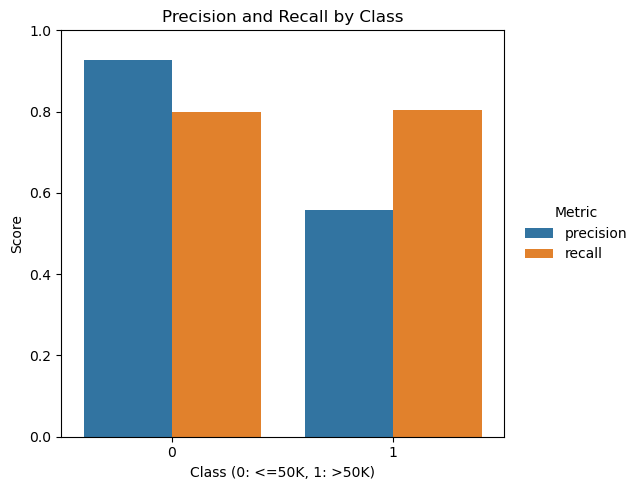

,class,precision,recall
0,0,0.927632,0.798414
1,1,0.558313,0.803571


In [22]:
# Visualize precision and recall from the classification report.
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T

# Keep only class rows (exclude accuracy/macro avg/weighted avg).
class_rows = [str(c) for c in sorted(set(y_test))]
metrics_df = report_df.loc[class_rows, ["precision", "recall"]].reset_index()
metrics_df = metrics_df.rename(columns={"index": "class"})
metrics_long = metrics_df.melt(id_vars="class", var_name="metric", value_name="score")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=metrics_long,
    x="class",
    y="score",
    hue="metric",
    palette=["#1f77b4", "#ff7f0e"],
    ax=ax
    )
ax.set_ylim(0, 1)
ax.set_title("Precision and Recall by Class")
ax.set_xlabel("Class (0: <=50K, 1: >50K)")
ax.set_ylabel("Score")
ax.legend(title="Metric", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

display(metrics_df)

In [23]:
# Export confusion matrix for cross-model comparison plots.
os.makedirs("exports", exist_ok=True)
nb_cm_path = os.path.join("exports", "naive_bayes_confusion_matrix.csv")
np.savetxt(nb_cm_path, cm, fmt="%d", delimiter=",")
print(f"Saved Naive Bayes confusion matrix to: {nb_cm_path}")

Saved Naive Bayes confusion matrix to: exports\naive_bayes_confusion_matrix.csv


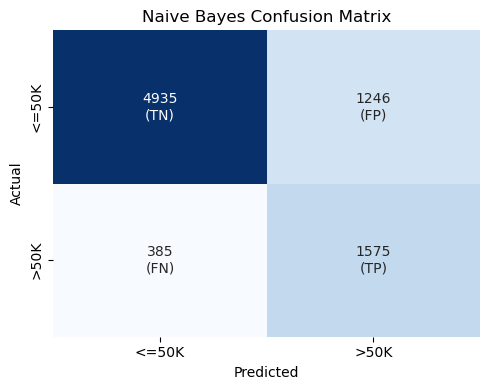

In [24]:
# Confusion matrix heat map
cell_labels = np.array([["TN", "FP"], ["FN", "TP"]])
annot_labels = np.array([
    [f"{cm[i, j]}\n({cell_labels[i, j]})" for j in range(2)]
    for i in range(2)
], dtype=object)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()

## Feature Importance

Understand which features are most indicative of high vs. low income using log-likelihood ratios.

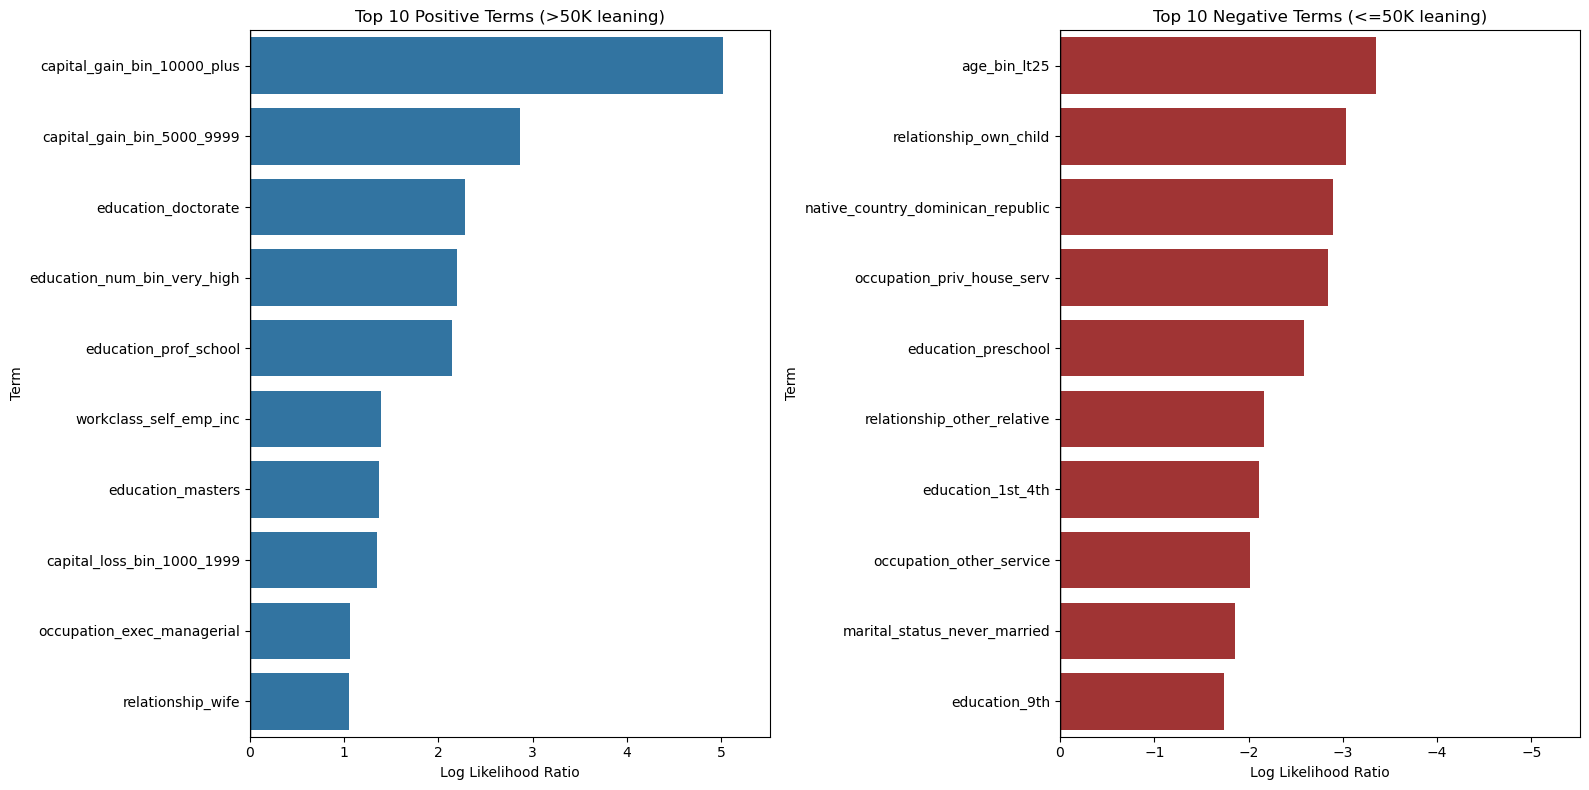

Top 10 positive terms by relative importance (largest absolute value first):


,term,p_term_given_low,p_term_given_high,log_likelihood_ratio
6,capital_gain_bin_10000_plus,0.000647,0.097399,5.013897
8,capital_gain_bin_5000_9999,0.005501,0.096209,2.861539
23,education_doctorate,0.004099,0.040116,2.281016
29,education_num_bin_very_high,0.010355,0.093660,2.202157
31,education_prof_school,0.006310,0.053714,2.141486
96,workclass_self_emp_inc,0.019848,0.079551,1.388303
25,education_masters,0.030851,0.121877,1.373855
10,capital_loss_bin_1000_1999,0.020441,0.079211,1.354567
68,occupation_exec_managerial,0.087050,0.250722,1.057860
90,relationship_wife,0.033008,0.094340,1.050153


Top 10 negative terms by relative importance (largest absolute value first):


,term,p_term_given_low,p_term_given_high,log_likelihood_ratio
5,age_bin_lt25,0.223613,0.007819,-3.353340
88,relationship_own_child,0.200690,0.009689,-3.030779
48,native_country_dominican_republic,0.003074,0.000170,-2.895134
73,occupation_priv_house_serv,0.005825,0.000340,-2.841066
30,education_preschool,0.002265,0.000170,-2.589752
87,relationship_other_relative,0.038294,0.004420,-2.159251
16,education_1st_4th,0.007011,0.000850,-2.110179
72,occupation_other_service,0.128041,0.016998,-2.019244
41,marital_status_never_married,0.409525,0.063743,-1.860138
19,education_9th,0.020225,0.003570,-1.734486


In [25]:
# Relative importance of terms using log likelihood ratio between classes.
feature_names = vectorizer.get_feature_names_out()
cond_prob = np.exp(B.feature_log_prob_)

# Class order follows model classes: 0 -> <=50K, 1 -> >50K
p_low = cond_prob[0]
p_high = cond_prob[1]

eps = 1e-12
log_lr = np.log((p_high + eps) / (p_low + eps))

importance_df = pd.DataFrame({
    "term": feature_names,
    "p_term_given_low": p_low,
    "p_term_given_high": p_high,
    "log_likelihood_ratio": log_lr,
    "abs_log_likelihood_ratio": np.abs(log_lr)
})

top_n = 10

# Positive and negative groups, each ordered so largest absolute value appears at the top.
top_terms = importance_df[importance_df["log_likelihood_ratio"] > 0].nlargest(top_n, "log_likelihood_ratio")
top_terms = top_terms.sort_values("abs_log_likelihood_ratio", ascending=False)

bottom_terms = importance_df[importance_df["log_likelihood_ratio"] < 0].nsmallest(top_n, "log_likelihood_ratio")
bottom_terms = bottom_terms.sort_values("abs_log_likelihood_ratio", ascending=False)

# Use the same absolute x-limit on both subplots for direct bar-length comparison.
pos_max = top_terms["log_likelihood_ratio"].max() if len(top_terms) else 0
neg_abs_max = np.abs(bottom_terms["log_likelihood_ratio"].min()) if len(bottom_terms) else 0
shared_abs_limit = max(pos_max, neg_abs_max) * 1.1 if max(pos_max, neg_abs_max) > 0 else 1

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

sns.barplot(
    data=top_terms,
    x="log_likelihood_ratio",
    y="term",
    order=top_terms["term"],
    color="#1f77b4",
    ax=axes[0]
    )
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlim(0, shared_abs_limit)
axes[0].set_title("Top 10 Positive Terms (>50K leaning)")
axes[0].set_xlabel("Log Likelihood Ratio")
axes[0].set_ylabel("Term")

sns.barplot(
    data=bottom_terms,
    x="log_likelihood_ratio",
    y="term",
    order=bottom_terms["term"],
    color="#b22222",
    ax=axes[1]
    )
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlim(0, -shared_abs_limit)
axes[1].set_title("Top 10 Negative Terms (<=50K leaning)")
axes[1].set_xlabel("Log Likelihood Ratio")
axes[1].set_ylabel("Term")

plt.tight_layout()
plt.show()

print("Top 10 positive terms by relative importance (largest absolute value first):")
display(top_terms[[
    "term",
    "p_term_given_low",
    "p_term_given_high",
    "log_likelihood_ratio"
]])

print("Top 10 negative terms by relative importance (largest absolute value first):")
display(bottom_terms[[
    "term",
    "p_term_given_low",
    "p_term_given_high",
    "log_likelihood_ratio"
]])

## Sensitivity Analysis

Compare Naive Bayes performance across different preprocessing choices and feature budgets to understand the trade-offs discussed in the binning explanation.

mode,max_features,both,raw
0,25,0.756418,0.726692
1,50,0.783933,0.762069
2,75,0.794865,0.770298
3,100,0.800639,0.779634
4,150,0.814028,0.790812
5,200,0.816362,0.798059
6,300,0.822995,0.806043
7,500,0.824100,0.809114
8,800,0.824100,0.809114
9,1000,0.824100,0.809114


mode,max_features,accuracy_diff_both_minus_raw
0,25,0.029726
1,50,0.021865
2,75,0.024567
3,100,0.021005
4,150,0.023216
5,200,0.018302
6,300,0.016951
7,500,0.014986
8,800,0.014986
9,1000,0.014986


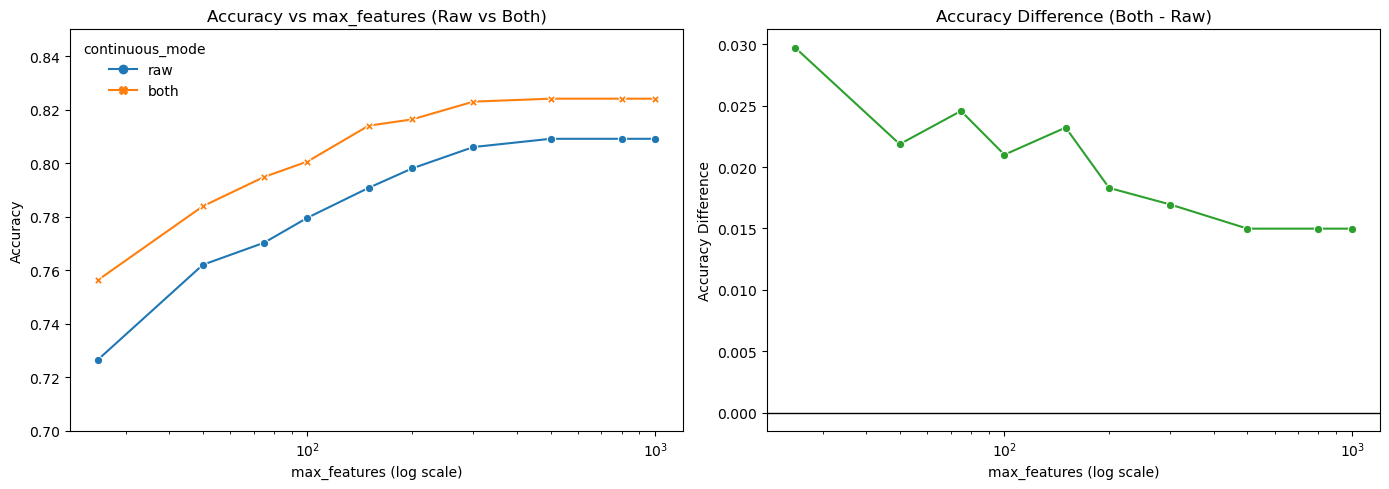

In [28]:
# Compare Naive Bayes accuracy for raw vs both continuous features across max_features.
feature_grid = [25, 50, 75, 100, 150, 200, 300, 500, 800, 1000]
modes = ["raw", "both"]
results = []

# Train/evaluate one model per preprocessing mode and feature-budget setting.
for mode in modes:
    mode_config = AdultPreprocessConfig(
        data_path="census+income/adult.data",
        continuous_mode=mode,
    )
    mode_preprocessor = AdultIncomePreprocessor(mode_config)
    mode_demographics, mode_income = mode_preprocessor.load()

    X_train_mode, X_test_mode, y_train_mode, y_test_mode = train_test_split(
        mode_demographics,
        mode_income,
        test_size=0.25,
        random_state=11,
        stratify=mode_income
    )

    for max_feat in feature_grid:
        vec = CountVectorizer(max_features=max_feat, stop_words="english")
        X_train_loop = vec.fit_transform(X_train_mode)
        X_test_loop = vec.transform(X_test_mode)

        model = BernoulliNB()
        model.fit(X_train_loop, y_train_mode)
        y_pred_loop = model.predict(X_test_loop)

        results.append({
            "max_features": max_feat,
            "mode": mode,
            "accuracy": accuracy_score(y_test_mode, y_pred_loop)
        })

perf_df = pd.DataFrame(results)
display(perf_df.pivot(index="max_features", columns="mode", values="accuracy").reset_index())

# Compute and display the accuracy difference: both - raw.
diff_df = perf_df.pivot(index="max_features", columns="mode", values="accuracy").reset_index()
diff_df["accuracy_diff_both_minus_raw"] = diff_df["both"] - diff_df["raw"]
display(diff_df[["max_features", "accuracy_diff_both_minus_raw"]])

# Plot absolute accuracy and pairwise difference across max_features.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=perf_df,
    x="max_features",
    y="accuracy",
    hue="mode",
    style="mode",
    markers=True,
    dashes=False,
    ax=axes[0]
    )
axes[0].set_xscale("log")
axes[0].set_ylim(0.7, 0.85)
axes[0].set_title("Accuracy vs max_features (Raw vs Both)")
axes[0].set_xlabel("max_features (log scale)")
axes[0].set_ylabel("Accuracy")
axes[0].legend(title="continuous_mode", frameon=False)

sns.lineplot(
    data=diff_df,
    x="max_features",
    y="accuracy_diff_both_minus_raw",
    marker="o",
    color="#2ca02c",
    ax=axes[1]
    )
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xscale("log")
axes[1].set_title("Accuracy Difference (Both - Raw)")
axes[1].set_xlabel("max_features (log scale)")
axes[1].set_ylabel("Accuracy Difference")

plt.tight_layout()
plt.show()